### Core functions

In [9]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm

import time
import warnings
from itertools import cycle, islice

import matplotlib.pyplot as plt
import numpy as np

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler

import src.estimators as estimators
import src.dataset_generator as dataset_generator
import src.auxiliar as aux
import src.entropy_estimator as entropy_estimator

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

In [7]:
reds = aux.CustomCmap([60/255,60/255,60/255], [196/255,60/255,60/255])
greens = aux.CustomCmap([0.1, 0.3, 0.1], [0.1, 0.8, 0.1])
blues = aux.CustomCmap([60/255,60/255,60/255], [45/255,159/255,255/255])
teals = aux.CustomCmap([60/255,60/255,60/255], [0/255,200/255,130/255])

In [10]:


# ============
# Generate datasets. We choose the size big enough to see the scalability
# of the algorithms, but not too big to avoid too long running times
# ============
n_samples = 500
noisy_circles = datasets.make_circles(
    n_samples=n_samples, factor=0.5, noise=0.05, random_state=42
)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=42)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=42)

### Example 1: Circles (Non-Overlapping)

In [ ]:
x_data, y_data = datasets.make_circles(
    n_samples=n_samples, factor=0.5, noise=0.05, random_state=42
)

estimation_measurement_threshold = 0.2
with np.errstate(divide='ignore', invalid='ignore'):
    c, p, h = entropy_estimator.classificability_estimator(x_data, y_data, distance_threshold=estimation_measurement_threshold, return_probs=True, return_entropies=True)

  0%|          | 0/500 [00:00<?, ?it/s]


				####################################################################
						  Numerical Classificability: 1.0000
				####################################################################



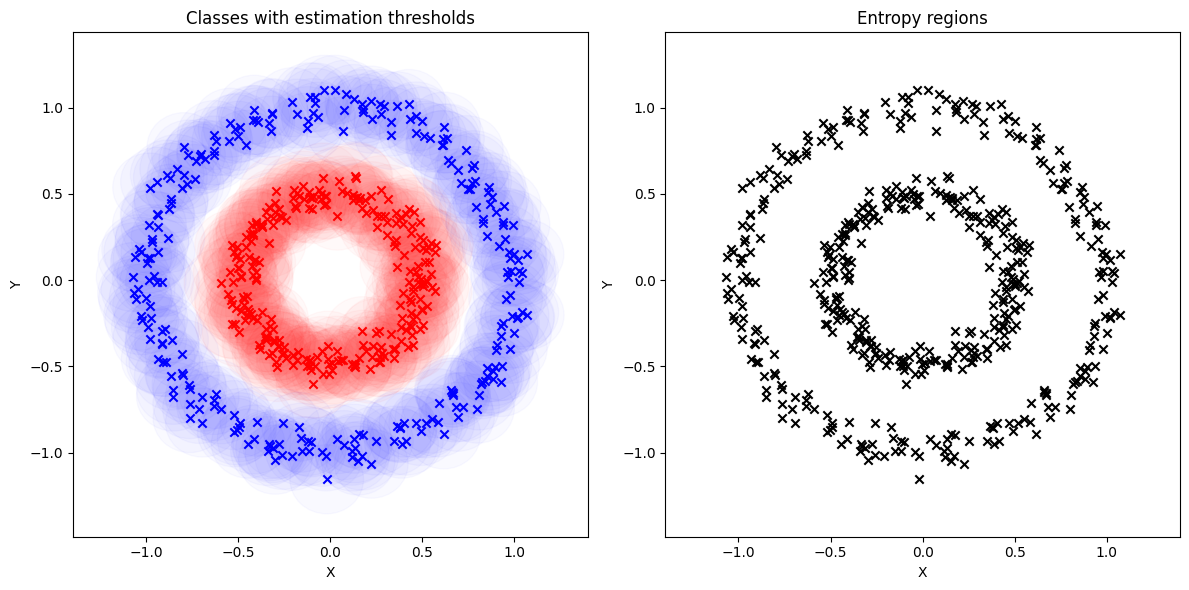

In [67]:
# Show classificability
aux.print_numerical_classificability(c)

# Plot informative figures

colors = ['b', 'r']
fig, ax = plt.subplots(1,2, figsize=(12,6))

for i in range(len(x_data)):
    circle = plt.Circle(x_data[i], estimation_measurement_threshold, color=colors[y_data[i]], alpha=0.025)
    ax[0].add_patch(circle)
ax[0].scatter(x_data[y_data==0][:,0], x_data[y_data==0][:,1], color=colors[0], marker='x')
ax[0].scatter(x_data[y_data==1][:,0], x_data[y_data==1][:,1], color=colors[1], marker='x')
ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')
ax[0].set_title('Classes with estimation thresholds')

h_norm = np.max(h) if np.max(h) > 0 else 1
for i in range(len(x_data)):
    circle = plt.Circle(x_data[i], estimation_measurement_threshold, color='y', alpha=np.max(h[i])/h_norm)
    ax[1].add_patch(circle)
ax[1].scatter(x_data[:,0], x_data[:,1], color='k', marker='x')
ax[1].set_xlabel('X')
ax[1].set_ylabel('Y')
ax[1].set_title('Entropy regions')

plt.tight_layout()
plt.show()

### Example 2: Circles (Overlapping)

In [ ]:
x_data, y_data = datasets.make_circles(
    n_samples=n_samples, factor=0.5, noise=0.15, random_state=42
)

estimation_measurement_threshold = 0.2
with np.errstate(divide='ignore', invalid='ignore'):
    c, p, h = entropy_estimator.classificability_estimator(x_data, y_data, distance_threshold=estimation_measurement_threshold, return_probs=True, return_entropies=True)


				####################################################################
						  Numerical Classificability: 0.9220
				####################################################################



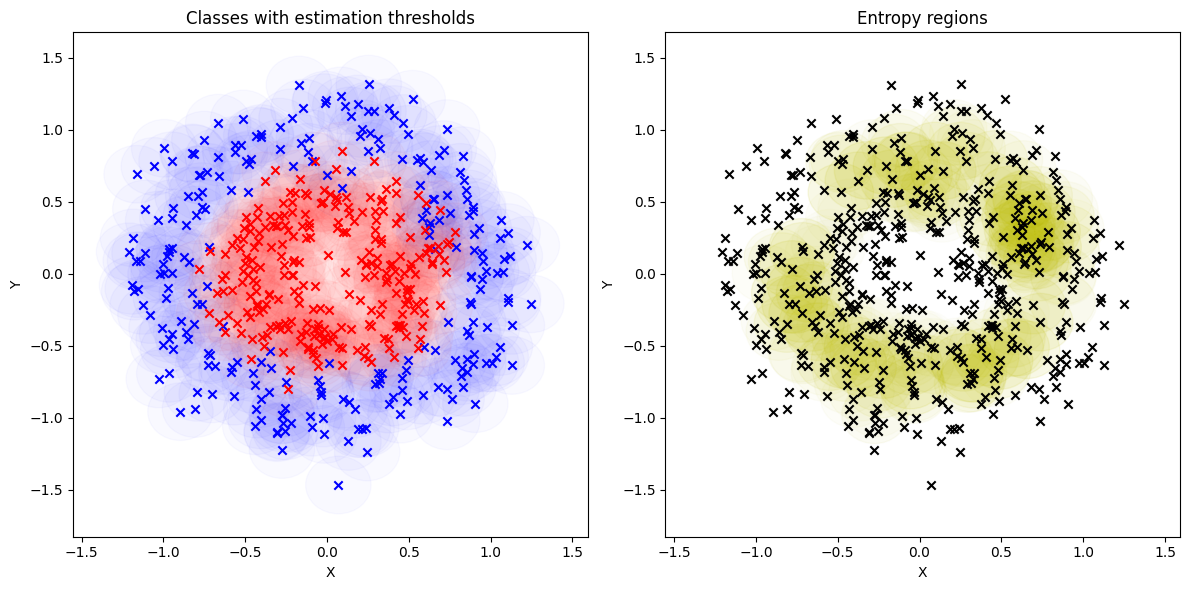

In [82]:
# Show classificability
aux.print_numerical_classificability(c)

# Plot informative figures

colors = ['b', 'r']
fig, ax = plt.subplots(1,2, figsize=(12,6))

for i in range(len(x_data)):
    circle = plt.Circle(x_data[i], estimation_measurement_threshold, color=colors[y_data[i]], alpha=0.025)
    ax[0].add_patch(circle)
ax[0].scatter(x_data[y_data==0][:,0], x_data[y_data==0][:,1], color=colors[0], marker='x')
ax[0].scatter(x_data[y_data==1][:,0], x_data[y_data==1][:,1], color=colors[1], marker='x')
ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')
ax[0].set_title('Classes with estimation thresholds')

h_norm = np.max(h) if np.max(h) > 0 else 1
for i in range(len(x_data)):
    circle = plt.Circle(x_data[i], estimation_measurement_threshold, color='y', alpha=0.1*np.max(h[i])/h_norm)
    ax[1].add_patch(circle)
ax[1].scatter(x_data[:,0], x_data[:,1], color='k', marker='x')
ax[1].set_xlabel('X')
ax[1].set_ylabel('Y')
ax[1].set_title('Entropy regions')

plt.tight_layout()
plt.show()

### Example 3: Overlapping as a function of noise

In [ ]:
# Fit several simple models to compareRemember my name fo
model_errors = []
noise_range = np.linspace(0, 0.5, 50)
for n in tqdm(noise_range):
    x_data, y_data = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=n, random_state=42)
    x_test, y_test = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=n, random_state=43)
    # Fit several simple models to compare
    errors = []
    for i in range(10):
        #clf = KNeighborsClassifier(3)
        clf = RandomForestClassifier()
        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(x_data, y_data)
        score = clf.score(x_test, y_test)
        errors.append(score)
    model_errors.append(errors)

100%|██████████| 50/50 [00:33<00:00,  1.47it/s]


In [6]:
# Fit several simple models to compare
classificabilities = []
noise_range = np.linspace(0, 0.5, 50)
classificability_thresholds = np.linspace(0, 0.25, 5)
for n in tqdm(noise_range):
    x_data, y_data = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=n, random_state=42)
    x_test, y_test = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=n, random_state=43)
    # Compute classificability
    cls_th = []
    for th in classificability_thresholds:
        with np.errstate(divide='ignore', invalid='ignore'):
            c, p, h = entropy_estimator.classificability_estimator(x_data, y_data, distance_threshold=th, return_probs=True, return_entropies=True)
        cls_th.append(c)
    classificabilities.append(cls_th)
classificabilities = np.array(classificabilities).T

100%|██████████| 50/50 [00:06<00:00,  7.40it/s]


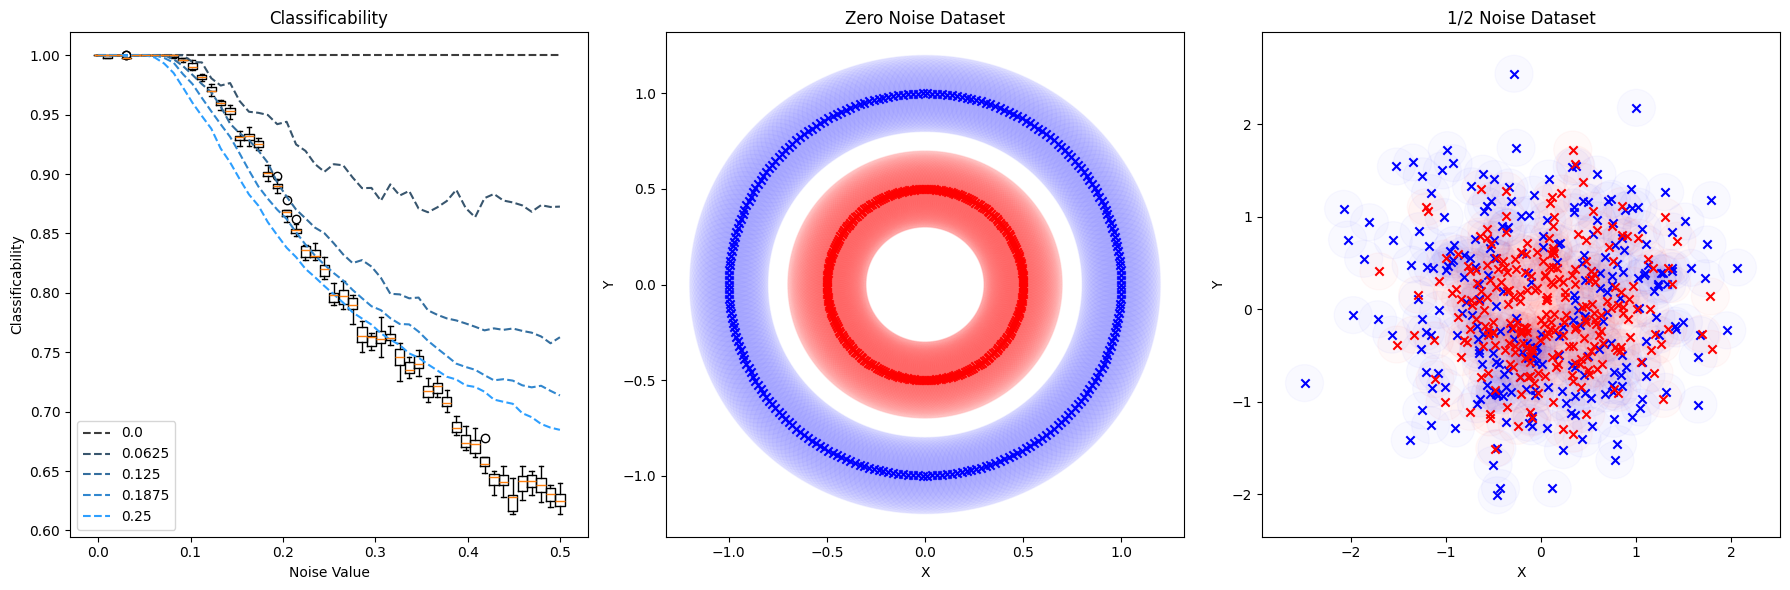

In [ ]:
colors = ['b', 'r']
fig, ax = plt.subplots(1,3, figsize=(18,6))

colors = blues(np.linspace(0,1,len(classificabilities)))
ax[0].boxplot(model_errors, positions=noise_range, widths=0.01, manage_ticks=False)
for i in range(len(classificabilities)):
    ax[0].plot(noise_range, classificabilities[i], color=colors[i], linestyle='--', label=classificability_thresholds[i])
ax[0].set_xlabel('Noise Value')
ax[0].set_ylabel('Classificability')
ax[0].set_title('Classificability')
ax[0].legend()

colors = ['b', 'r']
x_data, y_data = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05, random_state=42)
for i in range(len(x_data)):
    circle = plt.Circle(x_data[i], 0.2, color=colors[y_data[i]], alpha=0.025)
    ax[1].add_patch(circle)
ax[1].scatter(x_data[y_data==0][:,0], x_data[y_data==0][:,1], color=colors[0], marker='x')
ax[1].scatter(x_data[y_data==1][:,0], x_data[y_data==1][:,1], color=colors[1], marker='x')
ax[1].set_xlabel('X')
ax[1].set_ylabel('Y')
ax[1].set_title('Low Noise Dataset')

x_data, y_data = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.5, random_state=42)
for i in range(len(x_data)):
    circle = plt.Circle(x_data[i], 0.2, color=colors[y_data[i]], alpha=0.025)
    ax[2].add_patch(circle)
ax[2].scatter(x_data[y_data==0][:,0], x_data[y_data==0][:,1], color=colors[0], marker='x')
ax[2].scatter(x_data[y_data==1][:,0], x_data[y_data==1][:,1], color=colors[1], marker='x')
ax[2].set_xlabel('X')
ax[2].set_ylabel('Y')
ax[2].set_title('1/2 Noise Dataset')

plt.tight_layout()
plt.show()

### Example 4: Two moons

In [64]:
# Fit several simple models to compare
model_errors = []
noise_range = np.linspace(0, 0.5, 50)
for n in tqdm(noise_range):
    x_data, y_data = datasets.make_moons(n_samples=n_samples, noise=n, random_state=42)
    x_test, y_test = datasets.make_moons(n_samples=n_samples, noise=n, random_state=43)
    # Fit several simple models to compare
    errors = []
    for i in range(10):
        #clf = KNeighborsClassifier(3)
        clf = RandomForestClassifier()
        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(x_data, y_data)
        score = clf.score(x_test, y_test)
        errors.append(score)
    model_errors.append(errors)

100%|██████████| 50/50 [00:35<00:00,  1.39it/s]


In [65]:
# Fit several simple models to compare
classificabilities = []
noise_range = np.linspace(0, 0.5, 50)
classificability_thresholds = np.linspace(0, 0.25, 5)
for n in tqdm(noise_range):
    x_data, y_data = datasets.make_moons(n_samples=n_samples, noise=n, random_state=42)
    x_test, y_test = datasets.make_moons(n_samples=n_samples, noise=n, random_state=43)
    # Compute classificability
    cls_th = []
    for th in classificability_thresholds:
        with np.errstate(divide='ignore', invalid='ignore'):
            c, p, h = entropy_estimator.classificability_estimator(x_data, y_data, distance_threshold=th, return_probs=True, return_entropies=True)
        cls_th.append(c)
    classificabilities.append(cls_th)
classificabilities = np.array(classificabilities).T

100%|██████████| 50/50 [00:07<00:00,  6.37it/s]


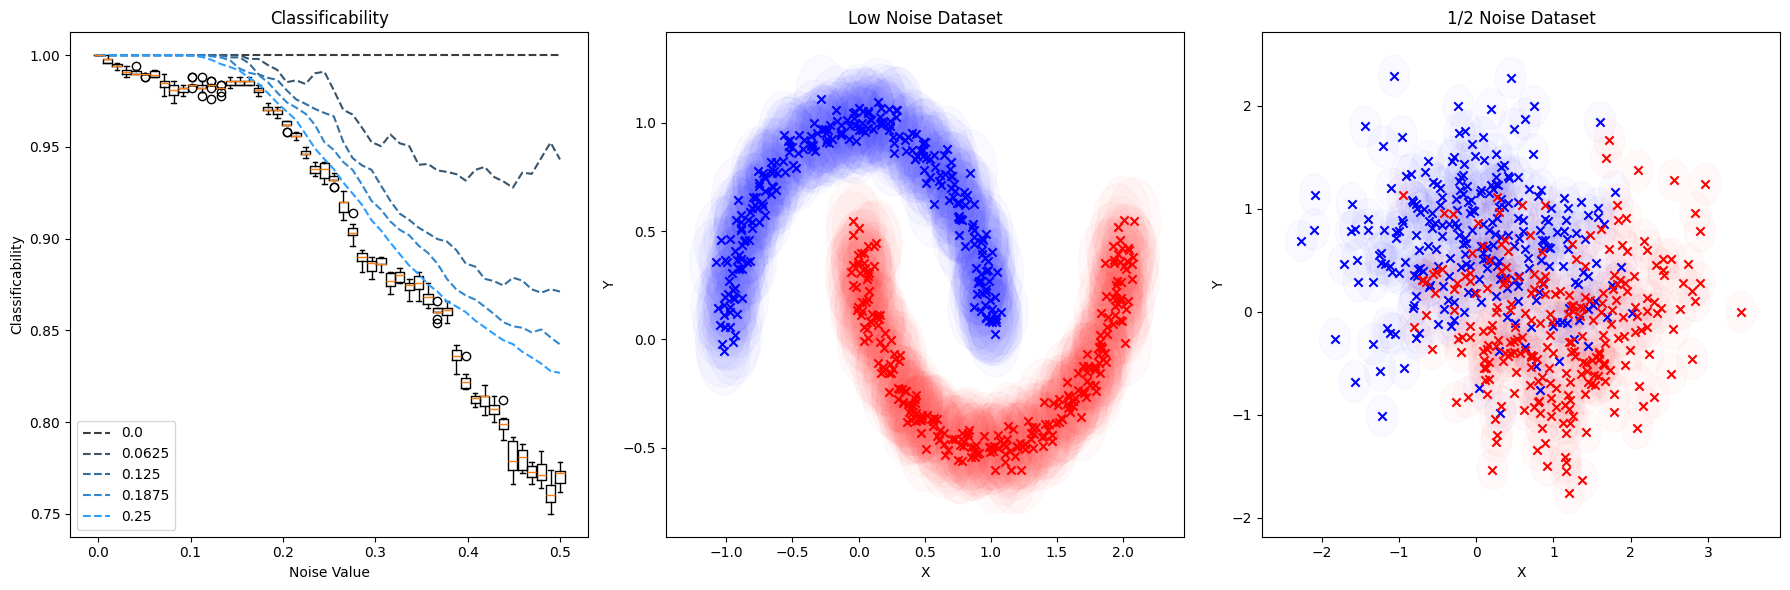

In [66]:
colors = ['b', 'r']
fig, ax = plt.subplots(1,3, figsize=(18,6))

colors = blues(np.linspace(0,1,len(classificabilities)))
ax[0].boxplot(model_errors, positions=noise_range, widths=0.01, manage_ticks=False)
for i in range(len(classificabilities)):
    ax[0].plot(noise_range, classificabilities[i], color=colors[i], linestyle='--', label=classificability_thresholds[i])
ax[0].set_xlabel('Noise Value')
ax[0].set_ylabel('Classificability')
ax[0].set_title('Classificability')
ax[0].legend()

colors = ['b', 'r']
x_data, y_data = datasets.make_moons(n_samples=n_samples, noise=0.05, random_state=42)
for i in range(len(x_data)):
    circle = plt.Circle(x_data[i], 0.2, color=colors[y_data[i]], alpha=0.025)
    ax[1].add_patch(circle)
ax[1].scatter(x_data[y_data==0][:,0], x_data[y_data==0][:,1], color=colors[0], marker='x')
ax[1].scatter(x_data[y_data==1][:,0], x_data[y_data==1][:,1], color=colors[1], marker='x')
ax[1].set_xlabel('X')
ax[1].set_ylabel('Y')
ax[1].set_title('Low Noise Dataset')

x_data, y_data = datasets.make_moons(n_samples=n_samples, noise=0.5, random_state=42)
for i in range(len(x_data)):
    circle = plt.Circle(x_data[i], 0.2, color=colors[y_data[i]], alpha=0.025)
    ax[2].add_patch(circle)
ax[2].scatter(x_data[y_data==0][:,0], x_data[y_data==0][:,1], color=colors[0], marker='x')
ax[2].scatter(x_data[y_data==1][:,0], x_data[y_data==1][:,1], color=colors[1], marker='x')
ax[2].set_xlabel('X')
ax[2].set_ylabel('Y')
ax[2].set_title('1/2 Noise Dataset')

plt.tight_layout()
plt.show()

### Example 5: Blobs

In [62]:
# Fit several simple models to compare
model_errors = []
noise_range = np.linspace(1, 10, 50)
for n in tqdm(noise_range):
    x_data, y_data = datasets.make_blobs(n_samples=n_samples, cluster_std=n, random_state=42)
    x_test, y_test = datasets.make_blobs(n_samples=n_samples, cluster_std=n, random_state=43)
    # Fit several simple models to compare
    errors = []
    for i in range(10):
        clf = LinearSVC()
        clf = make_pipeline(StandardScaler(), clf)
        clf.fit(x_data, y_data)
        score = clf.score(x_test, y_test)
        errors.append(score)
    model_errors.append(errors)

100%|██████████| 50/50 [00:00<00:00, 98.02it/s]


In [50]:
# Fit several simple models to compare
classificabilities = []
noise_range = np.linspace(1, 10, 50)
classificability_thresholds = np.linspace(0.5, 2.5, 5)
for n in tqdm(noise_range):
    x_data, y_data = datasets.make_blobs(n_samples=n_samples, cluster_std=n, random_state=42)
    x_test, y_test = datasets.make_blobs(n_samples=n_samples, cluster_std=n, random_state=43)
    # Compute classificability
    cls_th = []
    for th in classificability_thresholds:
        with np.errstate(divide='ignore', invalid='ignore'):
            c, p, h = entropy_estimator.classificability_estimator(x_data, y_data, distance_threshold=th, return_probs=True, return_entropies=True)
        cls_th.append(c)
    classificabilities.append(cls_th)
classificabilities = np.array(classificabilities).T

100%|██████████| 50/50 [00:06<00:00,  7.16it/s]


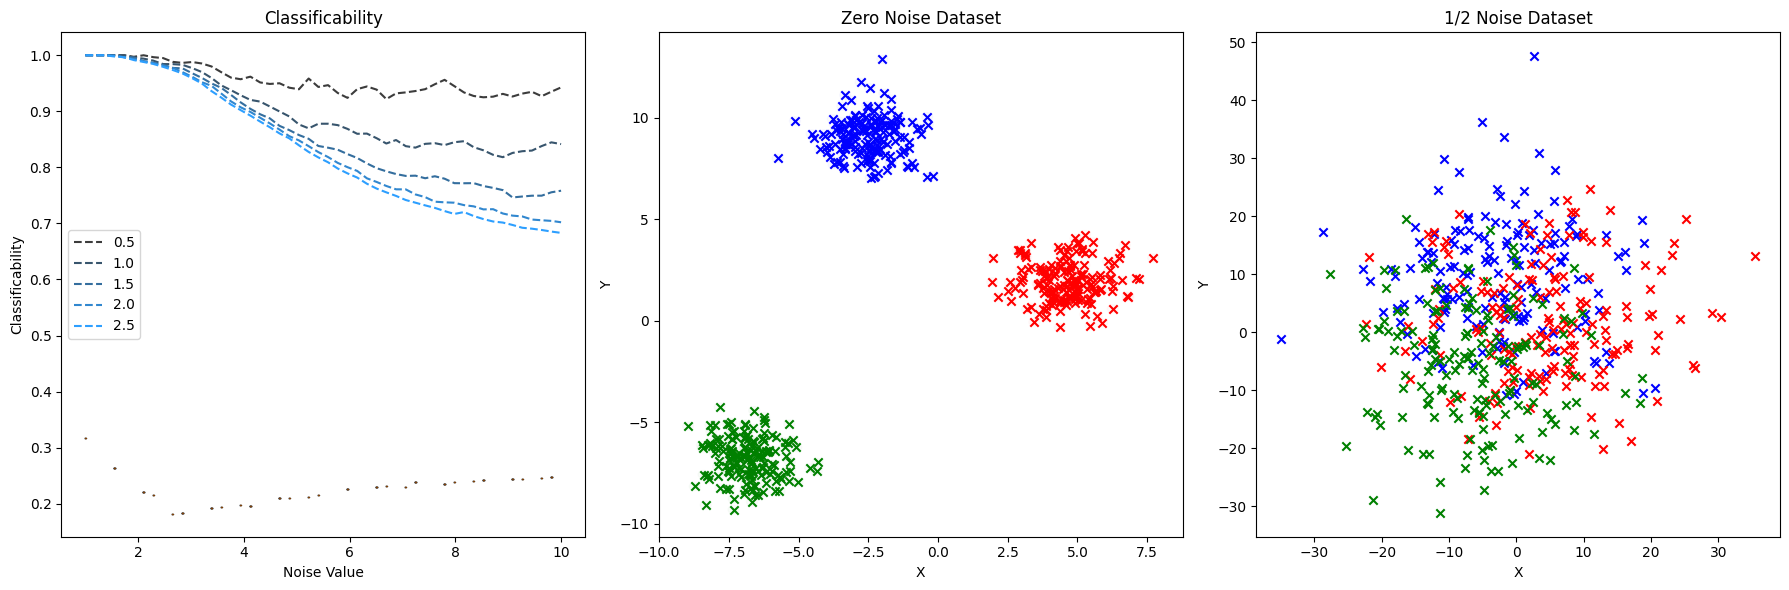

In [63]:
colors = ['b', 'r']
fig, ax = plt.subplots(1,3, figsize=(18,6))

colors = blues(np.linspace(0,1,len(classificabilities)))
ax[0].boxplot(model_errors, positions=noise_range, widths=0.01, manage_ticks=False)
for i in range(len(classificabilities)):
    ax[0].plot(noise_range, classificabilities[i], color=colors[i], linestyle='--', label=classificability_thresholds[i])
ax[0].set_xlabel('Noise Value')
ax[0].set_ylabel('Classificability')
ax[0].set_title('Classificability')
ax[0].legend()

colors = ['b', 'r', 'g']
x_data, y_data = datasets.make_blobs(n_samples=n_samples, cluster_std=1, random_state=42)
for i in range(len(x_data)):
    circle = plt.Circle(x_data[i], 0.2, color=colors[y_data[i]], alpha=0.025)
    ax[1].add_patch(circle)
for i in range(len(np.unique(y_data))):
    ax[1].scatter(x_data[y_data==i][:,0], x_data[y_data==i][:,1], color=colors[i], marker='x')
ax[1].set_xlabel('X')
ax[1].set_ylabel('Y')
ax[1].set_title('Zero Noise Dataset')

x_data, y_data = datasets.make_blobs(n_samples=n_samples, cluster_std=10, random_state=42)
for i in range(len(x_data)):
    circle = plt.Circle(x_data[i], 0.2, color=colors[y_data[i]], alpha=0.025)
    ax[2].add_patch(circle)
for i in range(len(np.unique(y_data))):
    ax[2].scatter(x_data[y_data==i][:,0], x_data[y_data==i][:,1], color=colors[i], marker='x')
ax[2].set_xlabel('X')
ax[2].set_ylabel('Y')
ax[2].set_title('1/2 Noise Dataset')

plt.tight_layout()
plt.show()